In [1]:
import pandas as pd
import numpy as np
import sqlite3

df = pd.read_csv('data.csv', encoding='latin1')

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (137839, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER       6.0   
1    536365     71053                  WHITE METAL LANTERN       6.0   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER       8.0   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE       6.0   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.       6.0   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [2]:
# Clean data
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

# SQLite database
conn = sqlite3.connect('retail.db')
df.to_sql('retail', conn, if_exists='replace', index=False)

# SQL Query 1 — Top 10 countries by revenue
query1 = """
SELECT Country,
       ROUND(SUM(TotalPrice), 2) as Total_Revenue,
       COUNT(DISTINCT CustomerID) as Customers
FROM retail
GROUP BY Country
ORDER BY Total_Revenue DESC
LIMIT 10
"""
result1 = pd.read_sql_query(query1, conn)
print(result1)

          Country  Total_Revenue  Customers
0  United Kingdom     1710238.36       1893
1     Netherlands       79017.00          5
2            EIRE       62350.55          3
3         Germany       55390.04         45
4          France       44868.35         42
5       Australia       41969.97          8
6           Spain       19407.47         15
7           Japan       13534.78          4
8          Sweden       12550.70          3
9        Portugal        9954.91         10


In [3]:
# Query 2 — RFM (Recency, Frequency, Monetary)
query2 = """
SELECT
    CustomerID,
    ROUND(julianday('2011-12-31') - julianday(MAX(InvoiceDate)), 0) as Recency,
    COUNT(DISTINCT InvoiceNo) as Frequency,
    ROUND(SUM(TotalPrice), 2) as Monetary
FROM retail
GROUP BY CustomerID
ORDER BY Monetary DESC
LIMIT 20
"""
rfm = pd.read_sql_query(query2, conn)
print(rfm.head(10))

   CustomerID Recency  Frequency  Monetary
0       14646    None         13  77521.38
1       12346    None          1  77183.60
2       18102    None          8  45279.41
3       12415    None          4  37842.74
4       14156    None         13  35496.87
5       17450    None          8  34149.54
6       15061    None         24  26120.40
7       17511    None          8  25337.26
8       14911    None         37  24622.38
9       15769    None          8  23181.48


In [4]:
# Fix date format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceDate'] = df['InvoiceDate'].dt.strftime('%Y-%m-%d')

# Database update
df.to_sql('retail', conn, if_exists='replace', index=False)

rfm = pd.read_sql_query(query2, conn)
print(rfm.head(10))

   CustomerID  Recency  Frequency  Monetary
0       14646    277.0         13  77521.38
1       12346    347.0          1  77183.60
2       18102    281.0          8  45279.41
3       12415    303.0          4  37842.74
4       14156    291.0         13  35496.87
5       17450    281.0          8  34149.54
6       15061    283.0         24  26120.40
7       17511    281.0          8  25337.26
8       14911    278.0         37  24622.38
9       15769    289.0          8  23181.48


In [5]:
# RFM Scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segments
def segment(row):
    r,f,m = int(row['R_Score']), int(row['F_Score']), int(row['M_Score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2:
        return 'Loyal'
    elif r >= 3:
        return 'Recent'
    elif f >= 3 and m >= 3:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Lost        8
Loyal       8
Champion    3
At Risk     1
Name: count, dtype: int64


In [6]:
query_full = """
SELECT
    CustomerID,
    ROUND(julianday('2011-12-31') - julianday(MAX(InvoiceDate)), 0) as Recency,
    COUNT(DISTINCT InvoiceNo) as Frequency,
    ROUND(SUM(TotalPrice), 2) as Monetary
FROM retail
GROUP BY CustomerID
"""
rfm = pd.read_sql_query(query_full, conn)

rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())
print("Total customers:", len(rfm))

Segment
Lost        800
Champion    524
Loyal       331
At Risk     239
Recent      199
Name: count, dtype: int64
Total customers: 2093


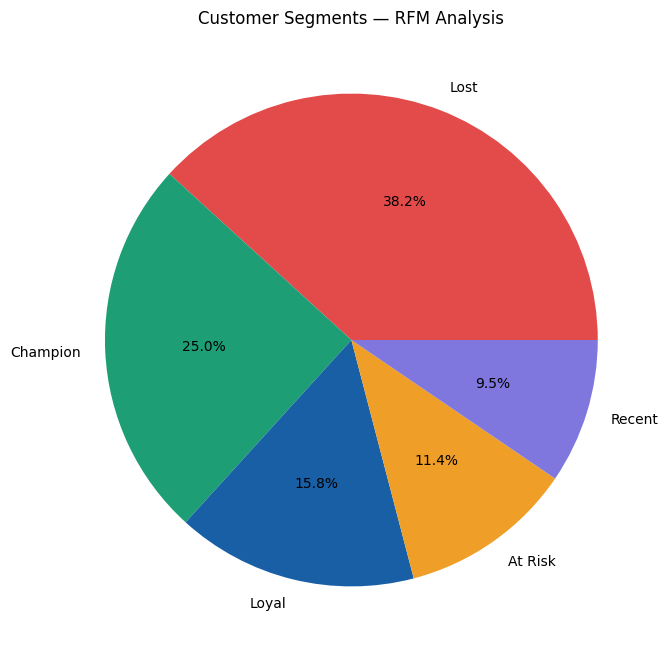

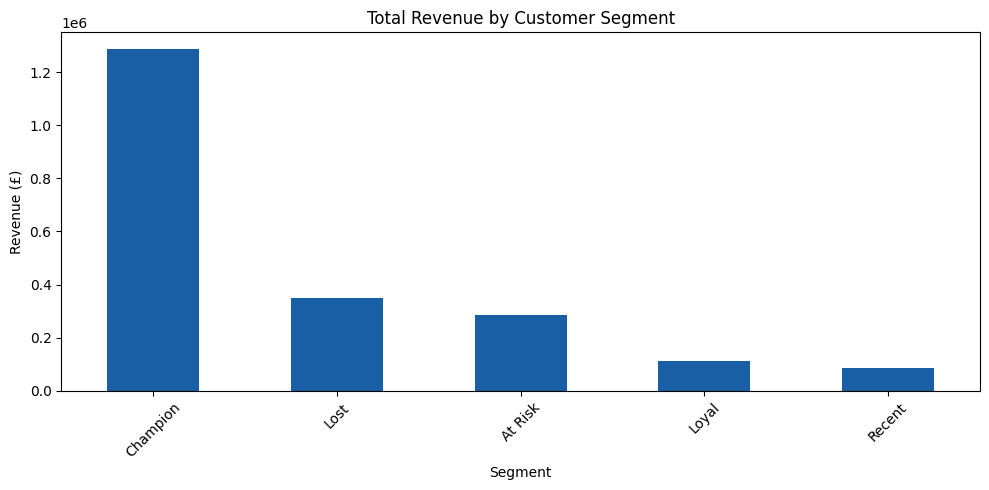

In [7]:
import matplotlib.pyplot as plt

# Segment pie chart
rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#E24B4A','#1D9E75','#185FA5','#EF9F27','#7F77DD'],
    figsize=(8,8)
)
plt.title('Customer Segments — RFM Analysis')
plt.ylabel('')
plt.show()

# Revenue by segment
rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False).plot(
    kind='bar', color='#185FA5', figsize=(10,5)
)
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()